In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

In [13]:
BASE_PATH = 'dataset'
RESULTS_FOLDER = os.path.join(BASE_PATH, 'results')

In [14]:
lr_pred = pd.read_csv(
    os.path.join(RESULTS_FOLDER, 'linear_regression_predictions.csv')
)

ridge_pred = pd.read_csv(
    os.path.join(RESULTS_FOLDER, 'ridge_regression_predictions.csv')
)

rf_pred = pd.read_csv(
    os.path.join(RESULTS_FOLDER, 'random_forest_predictions.csv')
)

xgb_pred = pd.read_csv(
    os.path.join(RESULTS_FOLDER, 'xgboost_predictions.csv')
)

se_pred = pd.read_csv(
    os.path.join(RESULTS_FOLDER, 'stacking_ensemble_predictions.csv')
)

In [15]:
# ambil kolom yang ditentukan
lr_pred = lr_pred[[
    'kabupaten_kota',
    'tahun',
    'actual',
    'prediction_lr'
]]

ridge_pred = ridge_pred[[
    'kabupaten_kota',
    'tahun',
    'prediction_ridge'
]]

rf_pred = rf_pred[[
    'kabupaten_kota',
    'tahun',
    'prediction_rf'
]]

xgb_pred = xgb_pred[[
    'kabupaten_kota',
    'tahun',
    'prediction_xgb'
]]

se_pred = se_pred[[
    'kabupaten_kota',
    'tahun',
    'prediction_stacking_ensemble'
]]

In [16]:
# merge semua prediction
baseline_predictions = lr_pred.merge(
    ridge_pred,
    on=['kabupaten_kota', 'tahun']
)

baseline_predictions = baseline_predictions.merge(
    rf_pred,
    on=['kabupaten_kota', 'tahun']
)

baseline_predictions = baseline_predictions.merge(
    xgb_pred,
    on=['kabupaten_kota', 'tahun']
)

baseline_predictions = baseline_predictions.merge(
    se_pred,
    on=['kabupaten_kota', 'tahun']
)

print(baseline_predictions.head(20))

          kabupaten_kota  tahun  actual  prediction_lr  prediction_ridge  \
0        Kab. Aceh Barat   2024   54.82      49.273620         49.428896   
1        Kab. Aceh Barat   2025   53.53      51.262015         50.581292   
2   Kab. Aceh Barat Daya   2024   55.15      50.869307         51.291792   
3   Kab. Aceh Barat Daya   2025   66.77      53.274884         52.472856   
4        Kab. Aceh Besar   2024   51.82      49.671488         49.722846   
5        Kab. Aceh Besar   2025   55.36      51.277436         50.404875   
6         Kab. Aceh Jaya   2024   53.86      48.358472         48.608419   
7         Kab. Aceh Jaya   2025   60.33      49.780166         49.334858   
8      Kab. Aceh Selatan   2024   46.44      51.292654         51.386068   
9      Kab. Aceh Selatan   2025   55.34      53.115976         52.335572   
10     Kab. Aceh Singkil   2024   37.90      48.083553         48.638056   
11     Kab. Aceh Singkil   2025   38.23      50.070254         49.655841   
12     Kab. 

In [17]:
baseline_predictions.to_csv(
    os.path.join(RESULTS_FOLDER, 'baseline_predictions.csv'),
    index=False
)

print("\nbaseline_predictions.csv berhasil disimpan.")


baseline_predictions.csv berhasil disimpan.


In [18]:
# Ambil data pertama 50 untuk visualisasi jelas
sample_data = baseline_predictions.head(50).reset_index(drop=True)

Plot 1 saved: plot_predictions_comparison.png


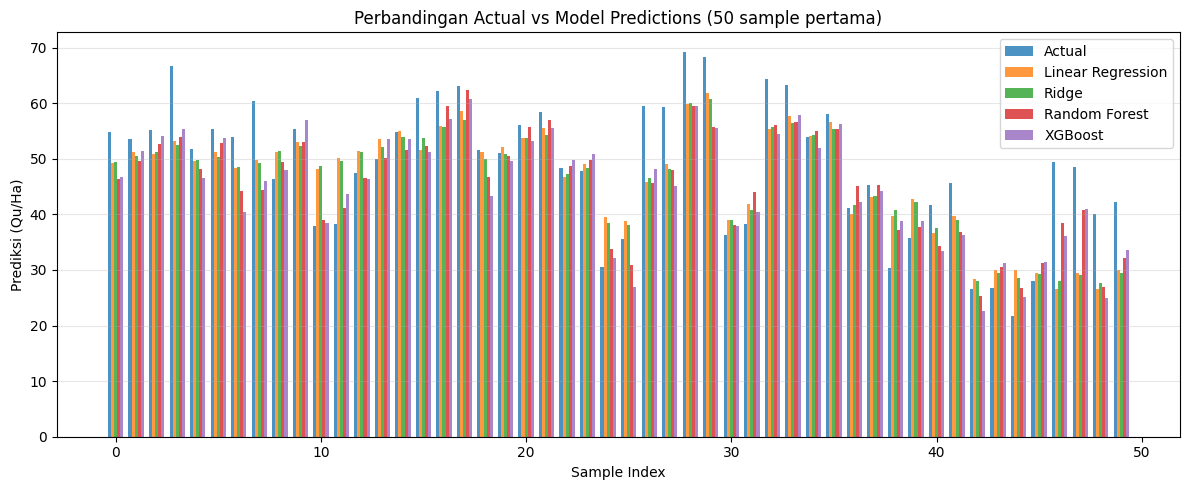

In [19]:
# Plot 1: Actual vs Predictions
fig, ax = plt.subplots(figsize=(12, 5))

x_pos = np.arange(len(sample_data))
width = 0.15

ax.bar(x_pos - 2*width, sample_data['actual'], width, label='Actual', alpha=0.8)
ax.bar(x_pos - width, sample_data['prediction_lr'], width, label='Linear Regression', alpha=0.8)
ax.bar(x_pos, sample_data['prediction_ridge'], width, label='Ridge', alpha=0.8)
ax.bar(x_pos + width, sample_data['prediction_rf'], width, label='Random Forest', alpha=0.8)
ax.bar(x_pos + 2*width, sample_data['prediction_xgb'], width, label='XGBoost', alpha=0.8)

ax.set_xlabel('Sample Index')
ax.set_ylabel('Prediksi (Qu/Ha)')
ax.set_title('Perbandingan Actual vs Model Predictions (50 sample pertama)')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'plot_predictions_comparison.png'), dpi=100, bbox_inches='tight')
print("Plot 1 saved: plot_predictions_comparison.png")
plt.show()

Plot 2 saved: plot_error_distribution.png


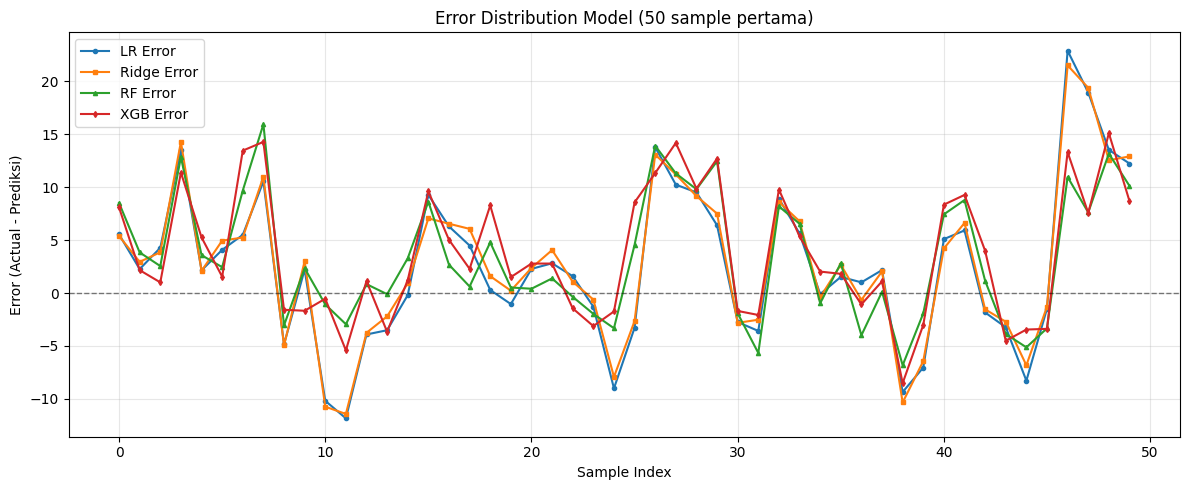

In [20]:
# Plot 2: Error Distribution
fig, ax = plt.subplots(figsize=(12, 5))

error_lr = sample_data['actual'] - sample_data['prediction_lr']
error_ridge = sample_data['actual'] - sample_data['prediction_ridge']
error_rf = sample_data['actual'] - sample_data['prediction_rf']
error_xgb = sample_data['actual'] - sample_data['prediction_xgb']

x_pos = np.arange(len(sample_data))

ax.plot(x_pos, error_lr, marker='o', label='LR Error', linewidth=1.5, markersize=3)
ax.plot(x_pos, error_ridge, marker='s', label='Ridge Error', linewidth=1.5, markersize=3)
ax.plot(x_pos, error_rf, marker='^', label='RF Error', linewidth=1.5, markersize=3)
ax.plot(x_pos, error_xgb, marker='d', label='XGB Error', linewidth=1.5, markersize=3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Sample Index')
ax.set_ylabel('Error (Actual - Prediksi)')
ax.set_title('Error Distribution Model (50 sample pertama)')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'plot_error_distribution.png'), dpi=100, bbox_inches='tight')
print("Plot 2 saved: plot_error_distribution.png")
plt.show()

Plot 3 saved: plot_stacking_ensemble.png


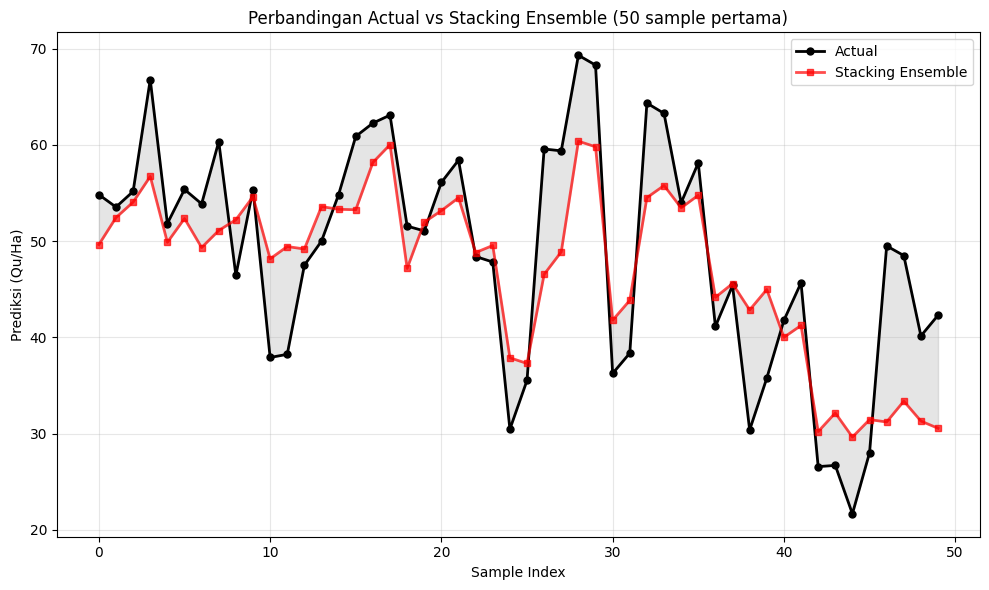


Semua plot berhasil dibuat dan disimpan.
Total plots: 3
Lokasi: dataset/results


In [21]:
# Plot 3: Actual vs Stacking Ensemble
fig, ax = plt.subplots(figsize=(10, 6))

sample_idx = np.arange(len(sample_data))

ax.plot(sample_idx, sample_data['actual'], marker='o', label='Actual', linewidth=2, markersize=5, color='black')
ax.plot(sample_idx, sample_data['prediction_stacking_ensemble'], marker='s', label='Stacking Ensemble', linewidth=2, markersize=5, color='red', alpha=0.7)
ax.fill_between(sample_idx, sample_data['actual'], sample_data['prediction_stacking_ensemble'], alpha=0.2, color='gray')

ax.set_xlabel('Sample Index')
ax.set_ylabel('Prediksi (Qu/Ha)')
ax.set_title('Perbandingan Actual vs Stacking Ensemble (50 sample pertama)')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'plot_stacking_ensemble.png'), dpi=100, bbox_inches='tight')
print("Plot 3 saved: plot_stacking_ensemble.png")
plt.show()

print("\nSemua plot berhasil dibuat dan disimpan.")
print(f"Total plots: 3")
print(f"Lokasi: {RESULTS_FOLDER}")

Plot 3 saved: plot_random_forest.png


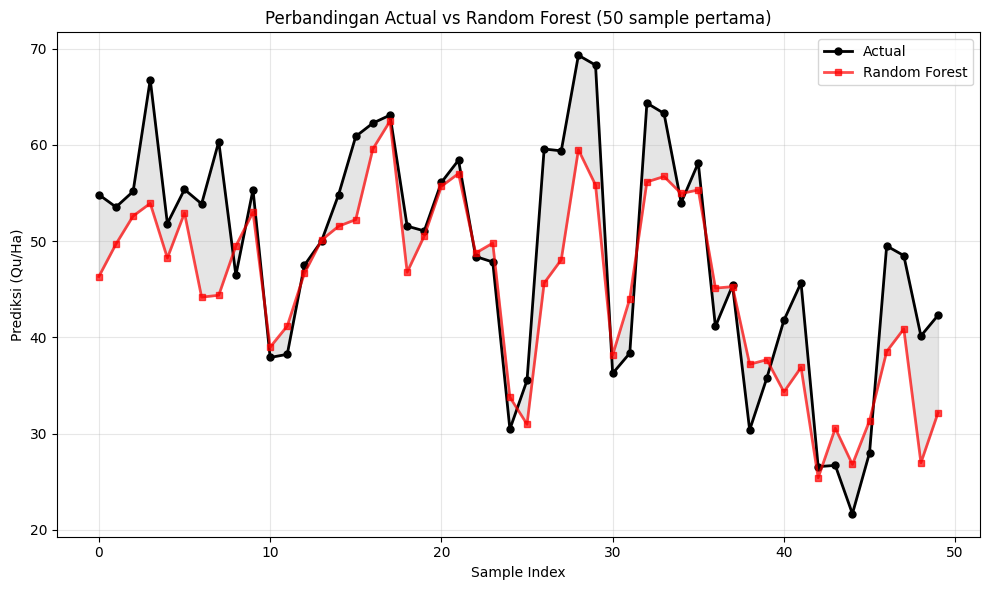


Semua plot berhasil dibuat dan disimpan.
Total plots: 3
Lokasi: dataset/results


In [22]:
# Plot 3: Actual vs Random Forest
fig, ax = plt.subplots(figsize=(10, 6))

sample_idx = np.arange(len(sample_data))

ax.plot(sample_idx, sample_data['actual'], marker='o', label='Actual', linewidth=2, markersize=5, color='black')
ax.plot(sample_idx, sample_data['prediction_rf'], marker='s', label='Random Forest', linewidth=2, markersize=5, color='red', alpha=0.7)
ax.fill_between(sample_idx, sample_data['actual'], sample_data['prediction_rf'], alpha=0.2, color='gray')

ax.set_xlabel('Sample Index')
ax.set_ylabel('Prediksi (Qu/Ha)')
ax.set_title('Perbandingan Actual vs Random Forest (50 sample pertama)')
ax.legend(loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_FOLDER, 'plot_random_forest.png'), dpi=100, bbox_inches='tight')
print("Plot 3 saved: plot_random_forest.png")
plt.show()

print("\nSemua plot berhasil dibuat dan disimpan.")
print(f"Total plots: 3")
print(f"Lokasi: {RESULTS_FOLDER}")